# Phase2: Deep Learning with Embeddings
Learn embedding techniques and neural architectures. Understand their strengths/weaknesses.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
import time
import joblib
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

try:
    import gensim
except ImportError:
    # Install gensim for easy embedding handling
    !pip install gensim -q

import gensim.downloader as api

# Check PyTorch setup
print(f" PyTorch version: {torch.__version__}")
print(f" CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f" GPU: {torch.cuda.get_device_name(0)}")
else:
    print("  Using CPU")

 PyTorch version: 2.11.0+cpu
 CUDA available: False
  Using CPU


## Load Data and Previous Results


In [2]:
# Load data
df = pd.read_csv('../data/customer_support_clean.csv')

# Load saved objects from Phase 1
label_encoder = joblib.load('../models/label_encoder.pkl')
tfidf = joblib.load('../models/tfidf_vectorizer.pkl')
lr_model = joblib.load('../models/lr_tfidf.pkl')

# Load splits

# X = df['instruction'].values
# y = label_encoder.transform(df['category'].values)
# X_np = np.asarray(X)

# X_temp, X_test, y_temp, y_test = train_test_split(
#     X_np, y, test_size=0.15, random_state=42, stratify=y
# )
# X_train, X_val, y_train, y_val = train_test_split(
#     X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
# )


# # Bundle all splits into a dictionary
# split_data = {
#     'X_train': X_train, 'y_train': y_train,
#     'X_val': X_val,   'y_val': y_val,
#     'X_test': X_test, 'y_test': y_test
# }

# # Save to disk
# with open('../data/data_splits.pkl', 'wb') as f:
#     pickle.dump(split_data, f)
# print(" Splits saved to ../data/data_splits.pkl")

with open('../data/data_splits.pkl', 'rb') as f:
    loaded = pickle.load(f)

X_train, y_train = loaded['X_train'], loaded['y_train']
X_val, y_val = loaded['X_val'], loaded['y_val']
X_test, y_test = loaded['X_test'], loaded['y_test']

print("✅ Data loaded and splits loaded from ../data/data_splits.pkl")

print(f" Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")


✅ Data loaded and splits loaded from ../data/data_splits.pkl
 Train: 18,820 | Val: 4,021 | Test: 4,031


## Experiment 2A - Pre-trained Word Embeddings

In [3]:
# Cell 3: Download and use GloVe embeddings
print(" Downloading GloVe embeddings...")
print("We'll use 50-dimensional GloVe (trained on Wikipedia)")

# Download GloVe (this may take a minute)
glove_vectors = api.load('glove-wiki-gigaword-50')

print(f" Loaded {len(glove_vectors)} word vectors")
print(f" Dimension: {glove_vectors.vector_size}")

# Test it out
test_word = "refund"
if test_word in glove_vectors:
    similar = glove_vectors.most_similar(test_word, topn=5)
    print(f"\n Words similar to '{test_word}':")
    for word, score in similar:
        print(f"  {word}: {score:.3f}")

We'll use 50-dimensional GloVe (trained on Wikipedia)
 Loaded 400000 word vectors
 Dimension: 50

 Words similar to 'refund':
  refunds: 0.919
  payment: 0.811
  reimbursement: 0.766
  payments: 0.758
  fees: 0.751


## Convert text to embeddings (averaging word vectors)

In [4]:
def text_to_embedding(text, model=glove_vectors):
    """Convert text to average of word embeddings"""
    words = text.lower().split()
    word_vectors = [model[word] for word in words if word in model]
    
    if len(word_vectors) > 0:
        return np.mean(word_vectors, axis=0)
    else:
        # Return zero vector if no words found
        return np.zeros(model.vector_size)

# Convert all texts to embeddings
print(" Converting texts to embeddings...")

X_train_emb = np.array([text_to_embedding(text) for text in tqdm(X_train)])
X_val_emb = np.array([text_to_embedding(text) for text in tqdm(X_val)])
X_test_emb = np.array([text_to_embedding(text) for text in tqdm(X_test)])

print(f"Shape: {X_train_emb.shape}")
print(f"Each text is now a {X_train_emb.shape[1]}-dimensional vector")

 Converting texts to embeddings...


100%|██████████| 4031/4031 [00:00<00:00, 5550.00it/s] 

Shape: (18820, 50)
Each text is now a 50-dimensional vector


## Train Logistic Regression on embeddings

In [17]:
print("EXPERIMENT 2A: GloVe + Logistic Regression")
print("=" * 60)

start_time = time.time()

lr_glove = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

lr_glove.fit(X_train_emb, y_train)

lr_train_time = time.time() - start_time

# Predict
y_val_pred = lr_glove.predict(X_val_emb)

# Metrics
acc = accuracy_score(y_val, y_val_pred)
f1_macro = f1_score(y_val, y_val_pred, average='macro')
f1_weighted = f1_score(y_val, y_val_pred, average='weighted')

print(f"Training time: {lr_train_time:.2f}s")
print(f"\nRESULTS:")
print(f"Accuracy:      {acc:.4f}")
print(f"F1 (Macro):    {f1_macro:.4f}")
print(f"F1 (Weighted): {f1_weighted:.4f}")

# Save
joblib.dump(lr_glove, '../models/lr_glove.pkl')

EXPERIMENT 2A: GloVe + Logistic Regression
Training time: 5.23s

RESULTS:
Accuracy:      0.9050
F1 (Macro):    0.9112
F1 (Weighted): 0.9047


['../models/lr_glove.pkl']

## Experiment 2B - Simple Neural Network
Building a simple feedforward neural network

In [6]:

class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.3):
        super(SimpleNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, output_dim)
        )
    
    def forward(self, x):
        return self.network(x)

# Model parameters
input_dim = 50  # GloVe dimension
hidden_dim = 128
output_dim = len(label_encoder.classes_)

model = SimpleNN(input_dim, hidden_dim, output_dim)

print("MODEL ARCHITECTURE")
print("=" * 60)
print(model)
print(f"\n Parameters: {sum(p.numel() for p in model.parameters()):,}")

MODEL ARCHITECTURE
SimpleNN(
  (network): Sequential(
    (0): Linear(in_features=50, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=11, bias=True)
  )
)

 Parameters: 15,499


## Create PyTorch datasets

In [7]:

class TextDataset(Dataset):
    def __init__(self, embeddings, labels):
        self.embeddings = torch.tensor(embeddings, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]

# Create datasets
train_dataset = TextDataset(X_train_emb, y_train)
val_dataset = TextDataset(X_val_emb, y_val)

# Create dataloaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

print(f"Datasets created")
print(f"Batch size: {batch_size}")
print(f"Batches per epoch: {len(train_loader)}")

Datasets created
Batch size: 64
Batches per epoch: 295


## Cell 9: Training function


In [8]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for embeddings, labels in loader:
        embeddings, labels = embeddings.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(embeddings)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Track metrics
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return total_loss / len(loader), correct / total

def eval_model(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for embeddings, labels in loader:
            embeddings, labels = embeddings.to(device), labels.to(device)
            outputs = model(embeddings)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return total_loss / len(loader), all_preds, all_labels

## Train the neural network


In [9]:
print("EXPERIMENT 2B: Simple Neural Network")
print("=" * 60)

# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleNN(input_dim, hidden_dim, output_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 10
best_f1 = 0
train_losses = []
val_f1_scores = []

start_time = time.time()

for epoch in range(num_epochs):
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_preds, val_labels = eval_model(model, val_loader, criterion, device)
    val_f1 = f1_score(val_labels, val_preds, average='macro')
    
    train_losses.append(train_loss)
    val_f1_scores.append(val_f1)
    
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")
    
    # Save best model
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), '../models/simple_nn_best.pt')

train_time = time.time() - start_time

print(f"\nTraining completed in {train_time:.1f}s")
print(f"Best validation F1: {best_f1:.4f}")

EXPERIMENT 2B: Simple Neural Network
Epoch 1/10 | Train Loss: 1.6982 | Train Acc: 0.4318 | Val Loss: 1.0310 | Val F1: 0.6549
Epoch 2/10 | Train Loss: 0.8925 | Train Acc: 0.7146 | Val Loss: 0.5917 | Val F1: 0.8319
Epoch 3/10 | Train Loss: 0.6350 | Train Acc: 0.8038 | Val Loss: 0.4334 | Val F1: 0.8767
Epoch 4/10 | Train Loss: 0.5130 | Train Acc: 0.8417 | Val Loss: 0.3537 | Val F1: 0.8953
Epoch 5/10 | Train Loss: 0.4412 | Train Acc: 0.8650 | Val Loss: 0.3018 | Val F1: 0.9081
Epoch 6/10 | Train Loss: 0.3859 | Train Acc: 0.8830 | Val Loss: 0.2569 | Val F1: 0.9234
Epoch 7/10 | Train Loss: 0.3529 | Train Acc: 0.8937 | Val Loss: 0.2434 | Val F1: 0.9242
Epoch 8/10 | Train Loss: 0.3235 | Train Acc: 0.9052 | Val Loss: 0.2127 | Val F1: 0.9375
Epoch 9/10 | Train Loss: 0.2975 | Train Acc: 0.9096 | Val Loss: 0.1978 | Val F1: 0.9426
Epoch 10/10 | Train Loss: 0.2783 | Train Acc: 0.9170 | Val Loss: 0.1975 | Val F1: 0.9397

Training completed in 22.8s
Best validation F1: 0.9426


## Visualize training curves


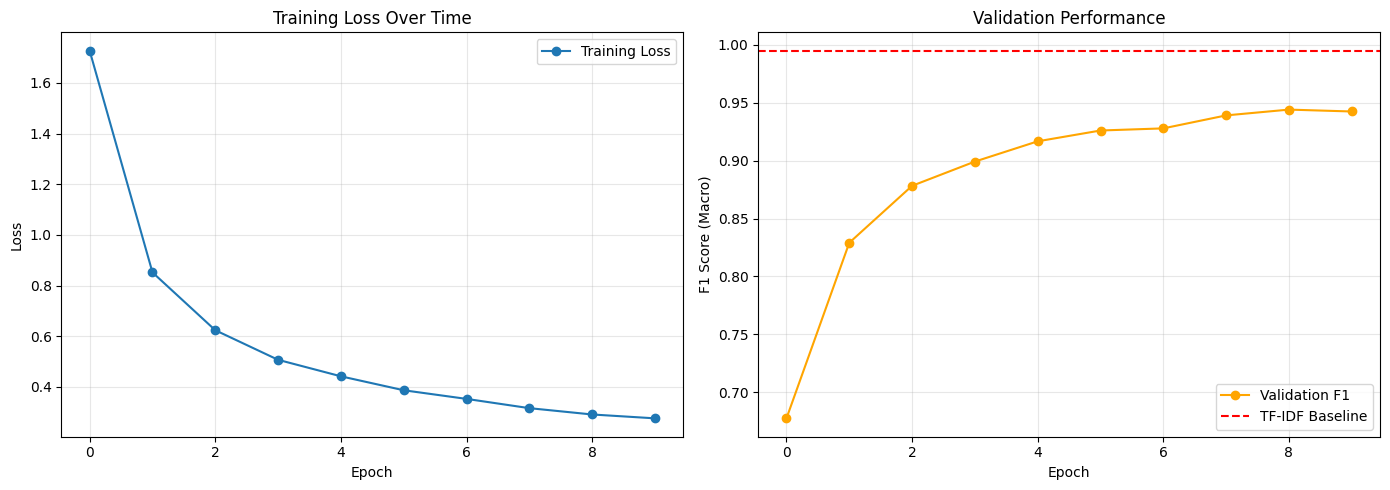

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(train_losses, label='Training Loss', marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss Over Time')
ax1.legend()
ax1.grid(True, alpha=0.3)

# F1 curve
ax2.plot(val_f1_scores, label='Validation F1', marker='o', color='orange')
ax2.axhline(y=0.995, color='r', linestyle='--', label='TF-IDF Baseline')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1 Score (Macro)')
ax2.set_title('Validation Performance')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../experiments/phase2_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Experiment 2C - LSTM Network


In [14]:
# First, we need to create sequences (not averaged embeddings)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenize texts
tokenizer = Tokenizer(num_words=5_000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Convert to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)

# Pad sequences to same length
max_length = 50  # Maximum words per text
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=max_length, padding='post')

print(f"Text sequences created")
print(f"Sequence shape: {X_train_pad.shape}")
print(f"Max sequence length: {max_length} words")

# Save tokenizer
with open('../models/tokenizer_2C.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

Text sequences created
Sequence shape: (18820, 50)
Max sequence length: 50 words


## LSTM Model Architecture


In [12]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, 
                 num_layers=2, dropout=0.3):
        super(LSTMClassifier, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embedding_dim, 
            hidden_dim, 
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True,
            bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)  # *2 for bidirectional
    
    def forward(self, x):
        # x shape: (batch_size, seq_length)
        embedded = self.embedding(x)  # (batch_size, seq_length, embedding_dim)
        
        # LSTM
        lstm_out, (hidden, cell) = self.lstm(embedded)
        
        # Use last hidden state from both directions
        # hidden shape: (num_layers * 2, batch_size, hidden_dim)
        hidden_fwd = hidden[-2, :, :]
        hidden_bwd = hidden[-1, :, :]
        hidden_concat = torch.cat((hidden_fwd, hidden_bwd), dim=1)
        
        # Dropout and final layer
        dropped = self.dropout(hidden_concat)
        output = self.fc(dropped)
        
        return output

# Model parameters
vocab_size = 5_000
embedding_dim = 100
hidden_dim = 128
num_layers = 2

lstm_model = LSTMClassifier(vocab_size, embedding_dim, hidden_dim, output_dim, num_layers)

print("LSTM MODEL ARCHITECTURE")
print("=" * 60)
print(lstm_model)
print(f"\n Total parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")

LSTM MODEL ARCHITECTURE
LSTMClassifier(
  (embedding): Embedding(5000, 100, padding_idx=0)
  (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=11, bias=True)
)

 Total parameters: 1,133,611


## Train LSTM


In [15]:
print("EXPERIMENT 2C: Bidirectional LSTM")
print("=" * 60)

# Create a DIFFERENT dataset class for sequences (integers, not floats)
class SequenceDataset(Dataset):
    def __init__(self, sequences, labels):
        # Sequences should be LongTensor (integers for embedding lookup)
        self.sequences = torch.LongTensor(sequences)
        self.labels = torch.LongTensor(labels)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

# Create datasets with sequences (using the new class)
train_dataset_lstm = SequenceDataset(X_train_pad, y_train)
val_dataset_lstm = SequenceDataset(X_val_pad, y_val)

train_loader_lstm = DataLoader(train_dataset_lstm, batch_size=64, shuffle=True)
val_loader_lstm = DataLoader(val_dataset_lstm, batch_size=64)

# Setup
lstm_model = lstm_model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)

# Training loop
num_epochs = 7
best_lstm_f1 = 0
lstm_train_losses = []
lstm_val_f1_scores = []

start_time = time.time()

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(lstm_model, train_loader_lstm, criterion, optimizer, device)
    val_loss, val_preds, val_labels = eval_model(lstm_model, val_loader_lstm, criterion, device)
    val_f1 = f1_score(val_labels, val_preds, average='macro')
    
    lstm_train_losses.append(train_loss)
    lstm_val_f1_scores.append(val_f1)
    
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")
    
    if val_f1 > best_lstm_f1:
        best_lstm_f1 = val_f1
        torch.save(lstm_model.state_dict(), '../models/lstm_best.pt')

lstm_train_time = time.time() - start_time

print(f"\n Training completed in {lstm_train_time:.1f}s")
print(f"    Best validation F1: {best_lstm_f1:.4f}")

EXPERIMENT 2C: Bidirectional LSTM
Epoch 1/7 | Train Loss: 0.0448 | Train Acc: 0.9909 | Val Loss: 0.0438 | Val F1: 0.9878
Epoch 2/7 | Train Loss: 0.0172 | Train Acc: 0.9956 | Val Loss: 0.0333 | Val F1: 0.9914
Epoch 3/7 | Train Loss: 0.0110 | Train Acc: 0.9974 | Val Loss: 0.0247 | Val F1: 0.9937
Epoch 4/7 | Train Loss: 0.0074 | Train Acc: 0.9984 | Val Loss: 0.0300 | Val F1: 0.9911
Epoch 5/7 | Train Loss: 0.0125 | Train Acc: 0.9977 | Val Loss: 0.0206 | Val F1: 0.9925
Epoch 6/7 | Train Loss: 0.0018 | Train Acc: 0.9995 | Val Loss: 0.0246 | Val F1: 0.9937
Epoch 7/7 | Train Loss: 0.0011 | Train Acc: 0.9998 | Val Loss: 0.0257 | Val F1: 0.9942

 Training completed in 1461.5s
    Best validation F1: 0.9942


## Cost-Benefit Analysis


In [18]:
# Compare ALL approaches
results_phase2 = pd.DataFrame({
    'Model': [
        'TF-IDF + Logistic Regression',
        'GloVe + Logistic Regression', 
        'GloVe + Neural Network',
        'LSTM (Bidirectional)'
    ],
    'F1 (Macro)': [0.9955, f1_macro, best_f1, best_lstm_f1],
    'Parameters': ['~53K', '~560', f"{sum(p.numel() for p in model.parameters()):,}", 
                   f"{sum(p.numel() for p in lstm_model.parameters()):,}"],
    'Training Time (s)': [2, lr_train_time, train_time, lstm_train_time],
    'Complexity': ['Low', 'Low', 'Medium', 'High']
})

print("=" * 80)
print(results_phase2.to_string(index=False))

results_phase2.to_csv('../experiments/phase2_results.csv', index=False)

                       Model  F1 (Macro) Parameters  Training Time (s) Complexity
TF-IDF + Logistic Regression    0.995500       ~53K           2.000000        Low
 GloVe + Logistic Regression    0.911152       ~560           5.233711        Low
      GloVe + Neural Network    0.942630     15,499          22.791644     Medium
        LSTM (Bidirectional)    0.994236  1,133,611        1461.541888       High


## Visualize the tradeoff


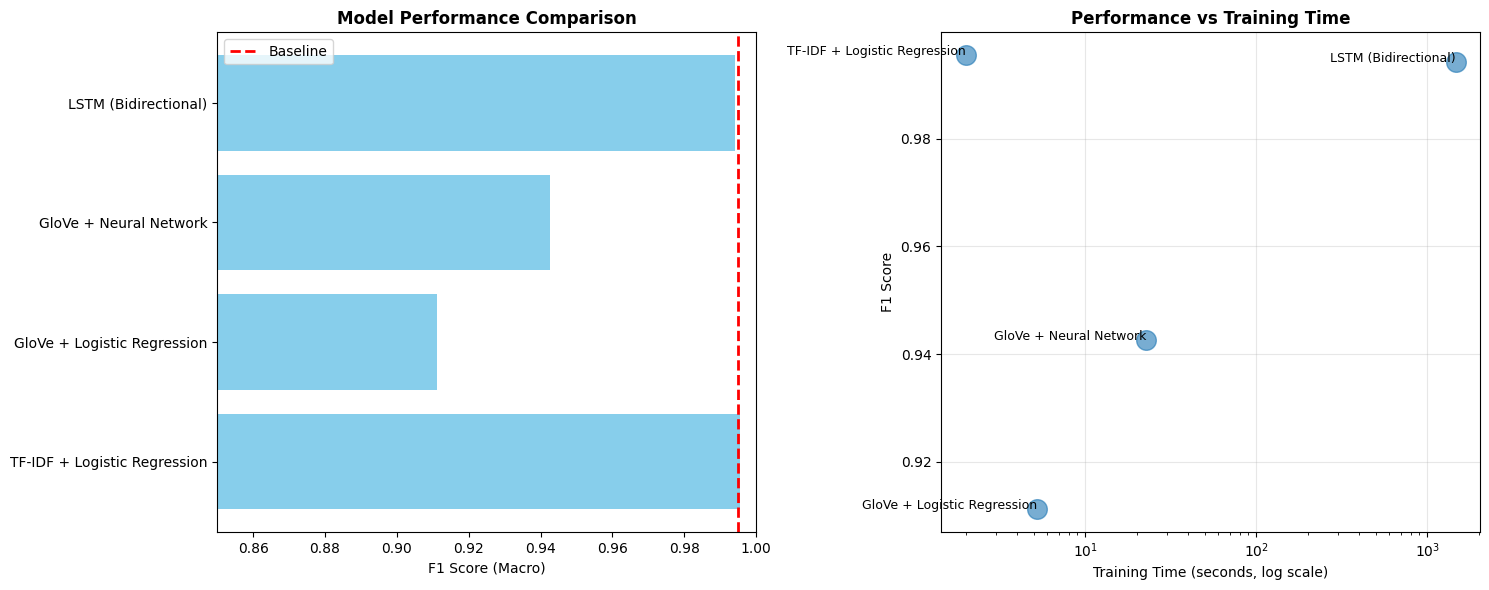

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# F1 Score comparison
axes[0].barh(results_phase2['Model'], results_phase2['F1 (Macro)'], color='skyblue')
axes[0].set_xlabel('F1 Score (Macro)')
axes[0].set_title('Model Performance Comparison', fontweight='bold')
axes[0].set_xlim([0.85, 1.0])
axes[0].axvline(x=0.995, color='r', linestyle='--', linewidth=2, label='Baseline')
axes[0].legend()

# Training time vs F1
# Convert training times to numeric
train_times_numeric = [2, lr_train_time, train_time, lstm_train_time]
axes[1].scatter(train_times_numeric, results_phase2['F1 (Macro)'], s=200, alpha=0.6)
for i, model in enumerate(results_phase2['Model']):
    axes[1].annotate(model,  #.split('+')[0].strip()
                    (train_times_numeric[i], results_phase2['F1 (Macro)'].iloc[i]),
                    fontsize=9, ha='right')
axes[1].set_xlabel('Training Time (seconds, log scale)')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Performance vs Training Time', fontweight='bold')
axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../experiments/phase2_tradeoff_analysis.png', dpi=150, bbox_inches='tight')
plt.show()